<a href="https://colab.research.google.com/github/thunyalak230/GE234_Thunyalak_6706615074/blob/main/Lab5_GE234_Rasterio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🛰️ Lab 5: การจัดการข้อมูล Raster ด้วย Rasterio
## วิชา GE 234 Basic Programming for Geographers

### 🎯 **วัตถุประสงค์**
1. เรียนรู้การใช้ **Rasterio** ในการอ่านและแสดงผลข้อมูล Raster
2. สามารถเข้าถึงข้อมูลเมตาของไฟล์ Raster เช่น ค่า Resolution และ CRS (Coordinate Reference System)
3. ใช้ **Rasterio** ในการตัด (Clip), บันทึก (Save), และวิเคราะห์ข้อมูล Raster
4. คำนวณค่าดัชนีพืชพรรณ **NDVI (Normalized Difference Vegetation Index)** จากข้อมูล Raster

---

## 🔹 ตัวอย่างที่ 1: อ่านข้อมูล Raster ด้วย Rasterio


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "/content/drive/MyDrive/GE234_2 2569/Thailand_S2_B8_B4_2023.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)


ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 185, 'height': 332, 'count': 2, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.04491576420597607, 0.0, 97.33246103435015,
       0.0, -0.04491576420597607, 20.48158847792509)}



## 🔹 ตัวอย่างที่ 2: แสดงผลข้อมูล Raster ด้วย Matplotlib


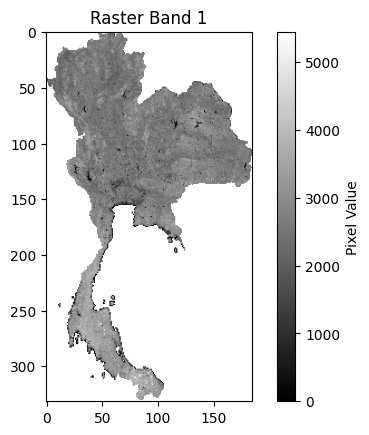

In [3]:

import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()



## 🔹 ตัวอย่างที่ 3: คำนวณค่า NDVI จากภาพ Raster


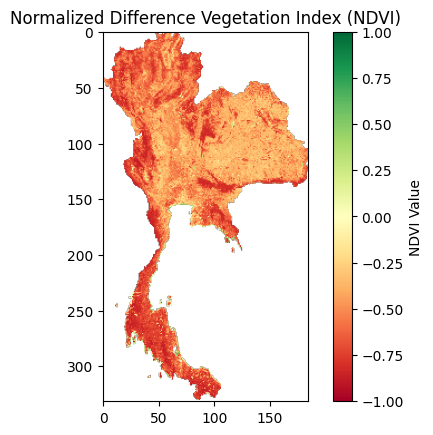

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# เปิดไฟล์ภาพดาวเทียม
with rasterio.open(raster_path) as dataset:
    # เนื่องจากไฟล์มีเพียง 2 แบนด์ และจากชื่อไฟล์ (B8_B4) คาดว่า Band 1 เป็น Red (B4) และ Band 2 เป็น NIR (B8)
    red = dataset.read(1).astype(float)  # ช่อง Red (เช่น Band 4)
    nir = dataset.read(2).astype(float)  # ช่อง NIR (เช่น Band 8)

# คำนวณ NDVI
ndvi = (nir - red) / (nir + red + 1e-10)  # หลีกเลี่ยงการหารด้วยศูนย์

# แสดงผล NDVI
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI)")
plt.show()


## 🔹 ตัวอย่างที่ 4: บันทึก NDVI เป็นไฟล์ GeoTIFF


In [5]:

# บันทึกไฟล์ NDVI เป็น GeoTIFF
ndvi_output = "ndvi_output.tif"
with rasterio.open(raster_path) as src:
    profile = src.profile
    profile.update(dtype=rasterio.float32, count=1)

    with rasterio.open(ndvi_output, "w", **profile) as dst:
        dst.write(ndvi.astype(rasterio.float32), 1)

print("บันทึกไฟล์ NDVI เรียบร้อย!")


บันทึกไฟล์ NDVI เรียบร้อย!



## 🔹 ตัวอย่างที่ 5: ตัด (Clip) ข้อมูล Raster ตามขอบเขตที่กำหนด


In [6]:

from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping

# โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
shapefile_path = "/content/drive/MyDrive/GE234_2 2569/tambol.shp"  # ใส่ path ของไฟล์ขอบเขต
gdf = gpd.read_file(shapefile_path)

# แปลง Polygon เป็นรูปแบบ GeoJSON
geometry = [mapping(gdf.geometry[0])]

# ตัดภาพ Raster
with rasterio.open(raster_path) as src:
    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่
out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform})

# บันทึกไฟล์ที่ถูกตัด
clipped_raster = "clipped_output.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("ตัดข้อมูล Raster สำเร็จ!")


ตัดข้อมูล Raster สำเร็จ!



# 📝 **กิจกรรมในแลป**

1. **แบบฝึกหัด 1**: ใช้ **Rasterio** อ่านข้อมูลภาพ **Raster** และแสดงผลด้วย Matplotlib  
2. **แบบฝึกหัด 2**: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้  
3. **แบบฝึกหัด 3**: ใช้ **NumPy และ Rasterio** คำนวณค่า NDVI และแสดงผลแผนที่  
4. **แบบฝึกหัด 4**: ใช้ **Rasterio** ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile  


แบบฝึกหัด 1 : ใช้ Rasterio อ่านข้อมูลภาพ Raster และแสดงผลด้วย Matplotlib

จำนวนแบนด์: 1
ขนาดภาพ (Width x Height): 185 x 332
ระบบพิกัด (CRS): EPSG:4326


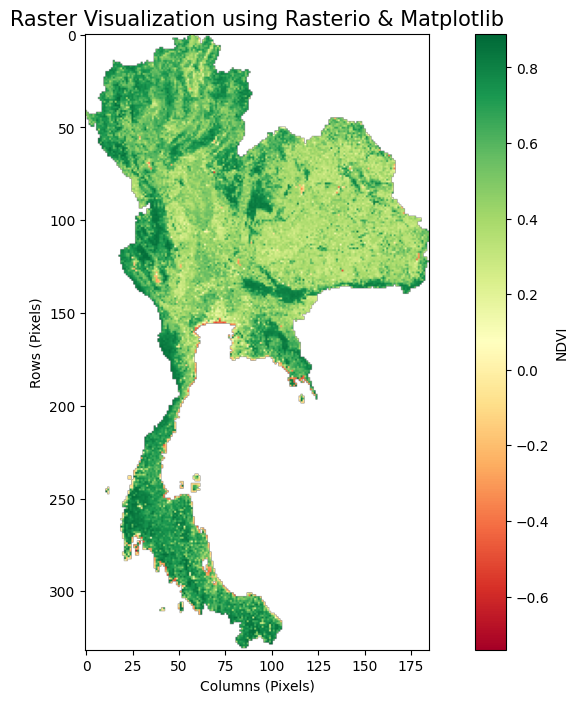

In [11]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np

# 1. ระบุ Path ของไฟล์ที่ต้องการอ่าน
# ตัวอย่าง: ไฟล์ที่โหลดมาจาก Google Drive หรือที่อยู่ใน Colab
file_path = "/content/drive/MyDrive/GE234_2 2569/Thailand_NDVI_2023.tif"

with rasterio.open(file_path) as src:
    data = src.read(1)

    # ดึงค่า Metadata พื้นฐานมาแสดงใน Console
    print(f"จำนวนแบนด์: {src.count}")
    print(f"ขนาดภาพ (Width x Height): {src.width} x {src.height}")
    print(f"ระบบพิกัด (CRS): {src.crs}")

    # 2. เริ่มการแสดงผลด้วย Matplotlib
    plt.figure(figsize=(12, 8))
    img = plt.imshow(data, cmap='RdYlGn')

    # เพิ่มแถบสี (Colorbar) เพื่อดูค่าตัวเลขในพิกเซล
    plt.colorbar(img, label='NDVI')

    # ตกแต่งแผนที่
    plt.title('Raster Visualization using Rasterio & Matplotlib', fontsize=15)
    plt.xlabel('Columns (Pixels)')
    plt.ylabel('Rows (Pixels)')

    # แสดงผล
    plt.show()

แบบฝึกหัด 2 : ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้

In [8]:
import rasterio

# ระบุ Path ของไฟล์ Raster ของคุณ
file_path = "/content/drive/MyDrive/GE234_2 2569/Thailand_NDVI_2023.tif"

with rasterio.open(file_path) as src:
    # 1. ดึง Metadata พื้นฐานทั้งหมดในรูปแบบ Dictionary
    meta = src.meta
    print(meta)
    print("\n--- Detailed Information ---")

    # 2. ดึงค่าแยกรายตัว
    print(f"Driver (รูปแบบไฟล์): {src.driver}")
    print(f"DataType (ชนิดข้อมูล): {src.dtypes[0]}")
    print(f"Count (จำนวนแบนด์): {src.count}")
    print(f"Width (ความกว้างพิกเซล): {src.width}")
    print(f"Height (ความสูงพิกเซล): {src.height}")
    print(f"CRS (ระบบพิกัด): {src.crs}")
    print(f"Transform (เมทริกซ์ตำแหน่ง): \n{src.transform}")
    print(f"Bounds (ขอบเขตพื้นที่): {src.bounds}")

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 185, 'height': 332, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.04491576420597607, 0.0, 97.33246103435015,
       0.0, -0.04491576420597607, 20.48158847792509)}

--- Detailed Information ---
Driver (รูปแบบไฟล์): GTiff
DataType (ชนิดข้อมูล): float32
Count (จำนวนแบนด์): 1
Width (ความกว้างพิกเซล): 185
Height (ความสูงพิกเซล): 332
CRS (ระบบพิกัด): EPSG:4326
Transform (เมทริกซ์ตำแหน่ง): 
| 0.04, 0.00, 97.33|
| 0.00,-0.04, 20.48|
| 0.00, 0.00, 1.00|
Bounds (ขอบเขตพื้นที่): BoundingBox(left=97.33246103435015, bottom=5.569554761541033, right=105.64187741245573, top=20.48158847792509)


แบบฝึกหัด 3: ใช้ NumPy และ Rasterio คำนวณค่า NDVI และแสดงผลแผนที่

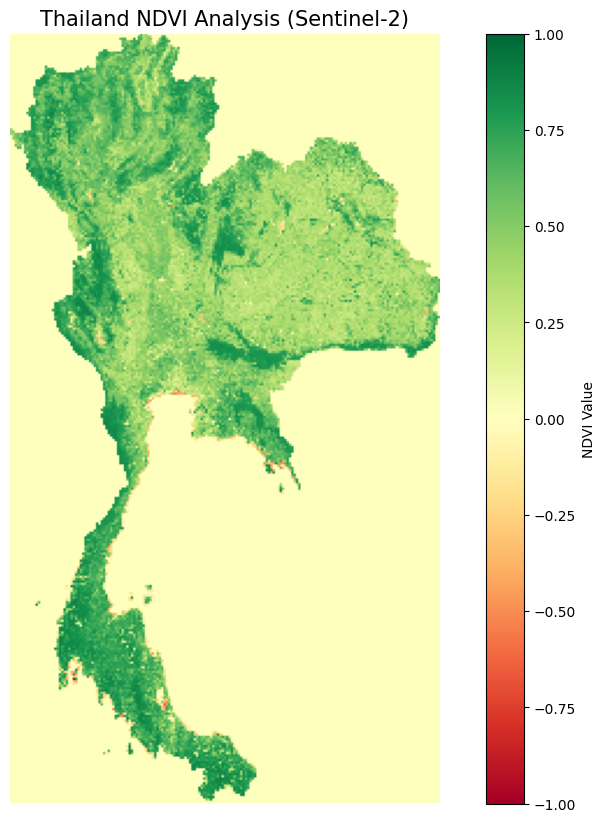

บันทึกไฟล์เรียบร้อยแล้ว


In [9]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# 1. เปิดไฟล์ Raster (ต้องเป็นไฟล์ที่มี Multiband เช่น B8 และ B4)
file_path = "/content/drive/MyDrive/GE234_2 2569/Thailand_S2_B8_B4_2023.tif"

with rasterio.open(file_path) as src:
    nir = src.read(1).astype('float32')
    red = src.read(2).astype('float32')

    # 2. คำนวณ NDVI ด้วย NumPy
    # ใช้ np.errstate เพื่อจัดการกรณีตัวหารเป็นศูนย์ (เช่น พื้นที่นอกขอบเขต)
    with np.errstate(divide='ignore', invalid='ignore'):
        ndvi = (nir - red) / (nir + red)

    # จัดการค่าที่เป็น Infinity หรือ NaN ให้เป็น 0 หรือค่าที่เหมาะสม
    ndvi = np.nan_to_num(ndvi, nan=0.0)

    # 3. แสดงผลด้วย Matplotlib
    plt.figure(figsize=(12, 10))

    # ใช้ colormap 'RdYlGn' (Red-Yellow-Green) เพื่อเลียนแบบสีพืชพรรณ
    img = plt.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)

    plt.colorbar(img, label='NDVI Value')
    plt.title('Thailand NDVI Analysis (Sentinel-2)', fontsize=15)
    plt.axis('off') # ปิดตัวเลขแกน x, y เพื่อความสวยงาม

    plt.show()

    # (Optional) บันทึกผลลัพธ์เป็นไฟล์ .tif ใหม่
    # สร้าง Metadata สำหรับไฟล์ NDVI (มีแค่ 1 แบนด์)
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "dtype": "float32",
        "count": 1
    })

# กำหนด Path ให้ชัดเจน
output_path = "/content/drive/MyDrive/GE234_2 2569/NDVI_Result.tif"

# ใช้ output_path ในการบันทึก
with rasterio.open(output_path, "w", **out_meta) as dest:
    dest.write(ndvi, 1)

print(f"บันทึกไฟล์เรียบร้อยแล้ว")

แบบฝึกหัด 4: ใช้ Rasterio ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile

ตัดข้อมูลสำเร็จ! บันทึกไฟล์ไว้ที่: /content/drive/MyDrive/GE234_2 2569/MajorStream_P13_clipped.tif


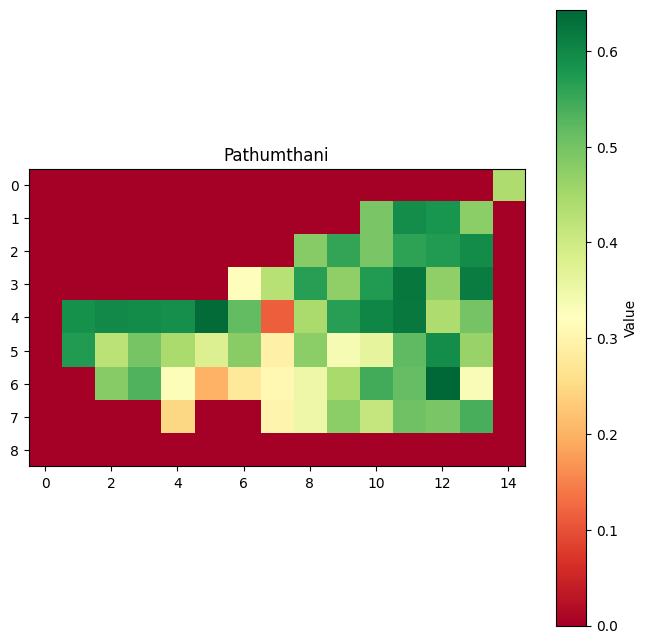

In [13]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.pyplot as plt

# 1. โหลดข้อมูลภาพ Raster (ไฟล์ใหญ่ที่มีทั้งประเทศไทย)
raster_path = "/content/drive/MyDrive/GE234_2 2569/Thailand_NDVI_2023.tif"

# 2. โหลดข้อมูลขอบเขต Shapefile (เช่น ขอบเขตตำบลหรืออำเภอ)
shapefile_path = "/content/drive/MyDrive/GE234_2 2569/ปทุมธานี"
gdf = gpd.read_file(shapefile_path)

# 3. ตรวจสอบและแปลงระบบพิกัด (CRS) ให้ตรงกัน **สำคัญมาก**
# ถ้า CRS ไม่ตรงกัน การตัดภาพจะว่างเปล่า
with rasterio.open(raster_path) as src:
    raster_crs = src.crs
    if gdf.crs != raster_crs:
        gdf = gdf.to_crs(raster_crs)
        print("แปลงพิกัด Shapefile ให้ตรงกับ Raster เรียบร้อยแล้ว")

# 4. เตรียมรูปทรงเรขาคณิต (Geometry) สำหรับการตัด
# ในที่นี้เราจะตัดตามขอบเขตแรกในไฟล์ (index 0) หรือจะรวมทั้งหมดก็ได้
geoms = [mapping(gdf.geometry[0])]

# 5. ทำการตัดภาพ (Masking)
with rasterio.open(raster_path) as src:
    # out_image: ข้อมูลพิกเซลที่ถูกตัดแล้ว, out_transform: ค่าตำแหน่งใหม่ของภาพที่ตัด
    out_image, out_transform = mask(src, geoms, crop=True)
    out_meta = src.meta.copy()

# 6. อัปเดต Metadata สำหรับไฟล์ใหม่
# ต้องเปลี่ยนค่าความกว้าง ความสูง และตำแหน่ง (Transform) ให้ตรงกับภาพที่ตัดออกมาใหม่
out_meta.update({
    "driver": "GTiff",
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# 7. บันทึกผลลัพธ์ลงใน Google Drive
output_clipped_file = "/content/drive/MyDrive/GE234_2 2569/MajorStream_P13_clipped.tif" # แก้ไขจากเดิมที่เป็นแค่ folder ให้มีชื่อไฟล์ด้วย
with rasterio.open(output_clipped_file, "w", **out_meta) as dest:
    dest.write(out_image)

print(f"ตัดข้อมูลสำเร็จ! บันทึกไฟล์ไว้ที่: {output_clipped_file}")

# 8. แสดงผลภาพที่ตัดเสร็จแล้ว
plt.figure(figsize=(8, 8))
plt.imshow(out_image[0], cmap='RdYlGn')
plt.title("Pathumthani")
plt.colorbar(label='Value')
plt.show()